In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

from sklearn.metrics import classification_report, confusion_matrix



In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", dataset_path)


Resuming download from 763363328 bytes (1700002107 bytes left)...
Resuming download to C:\Users\MOHD NADEEM\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\2.archive (763363328/2463365435) bytes left.


100%|██████████| 2.29G/2.29G [02:41<00:00, 10.5MB/s]


DataCorruptionError: The X-Goog-Hash header indicated a MD5 checksum of:

  kwdj41gOdt6cLISeyTO11g==

but the actual MD5 checksum of the downloaded contents was:

  LvTn0ws/829bCb1waQLfmA==


In [ ]:
import os

for root, dirs, files in os.walk(dataset_path):
    print(root)
    if len(files) > 0:
        print("Sample files:", files[:3])
    print("-"*50)

/kaggle/input/chest-xray-pneumonia
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
Sample files: ['.DS_Store']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
Sample files: ['.DS_Store']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
Sample files: ['person1947_bacteria_4876.jpeg', 'person1946_bacteria_4875.jpeg', 'person1952_bacteria_4883.jpeg']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
Sample files: ['NORMAL2-IM-1431-0001.jpeg', 'NORMAL2-IM-1440-0001.jpeg', 'NORMAL2-IM-1442-0001.jpeg']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
Sample files: ['.DS_St

In [ ]:
import os

base_path = os.path.join(dataset_path, "chest_xray")

train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")
val_path = os.path.join(base_path, "val")

print(train_path)
print(test_path)
print(val_path)

/kaggle/input/chest-xray-pneumonia/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/test
/kaggle/input/chest-xray-pneumonia/chest_xray/val


In [ ]:
print("Training")

print("NORMAL:", len(os.listdir(os.path.join(train_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(train_path, "PNEUMONIA"))))

print("\nTesting")

print("NORMAL:", len(os.listdir(os.path.join(test_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(test_path, "PNEUMONIA"))))

print("\nValidation")

print("NORMAL:", len(os.listdir(os.path.join(val_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(val_path, "PNEUMONIA"))))

Training
NORMAL: 1341
PNEUMONIA: 3875

Testing
NORMAL: 234
PNEUMONIA: 390

Validation
NORMAL: 8
PNEUMONIA: 8


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


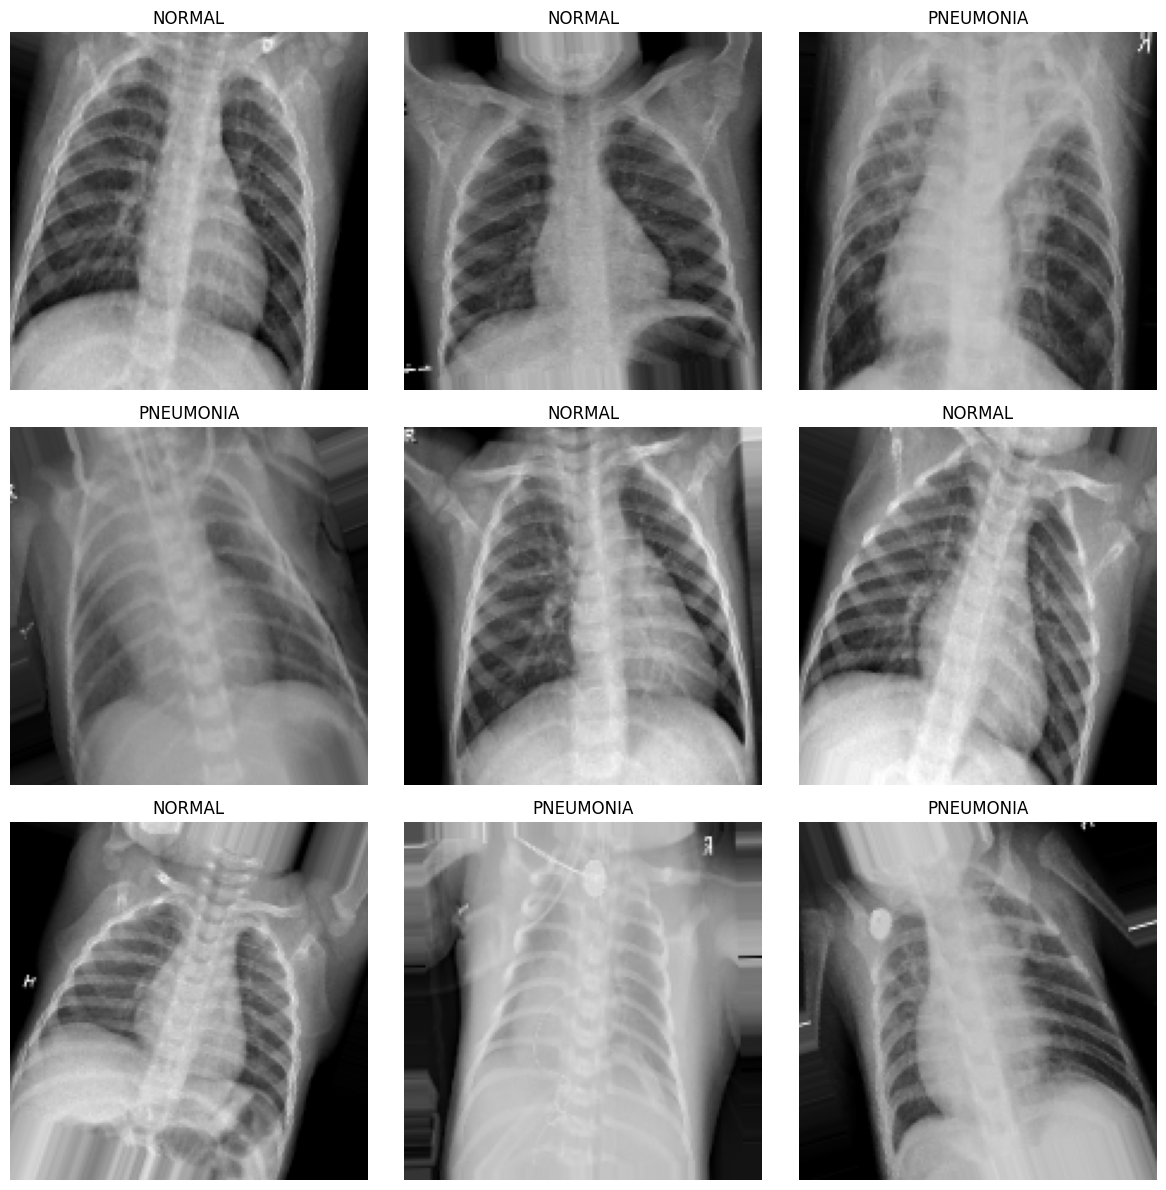

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,634,881 (13.87 MB)

 Trainable params: 3,633,921 (13.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 535ms/step - accuracy: 0.8294 - loss: 0.5970 - val_accuracy: 0.5000 - val_loss: 14.6108
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 89s 545ms/step - accuracy: 0.8808 - loss: 0.3278 - val_accuracy: 0.5000 - val_loss: 17.3654
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 559ms/step - accuracy: 0.8821 - loss: 0.2965 - val_accuracy: 0.5000 - val_loss: 26.7612
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 541ms/step - accuracy: 0.8898 - loss: 0.2867 - val_accuracy: 0.5000 - val_loss: 4.6525
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 90s 552ms/step - accuracy: 0.9015 - loss: 0.2399 - val_accuracy: 0.5000 - val_loss: 4.3636
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 562ms/step - accuracy: 0.9189 - loss: 0.2149 - val_accuracy: 0.5000 - val_loss: 26.5114
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 90s 550ms/step - accuracy: 0.9147 - loss: 0.2213 - val_accuracy: 0.5625 - val_loss: 4.6364
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 562ms/step - accuracy: 0.9195 - los

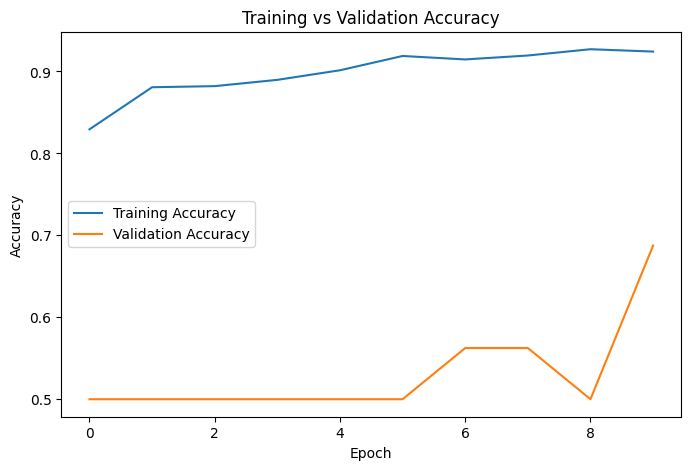

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

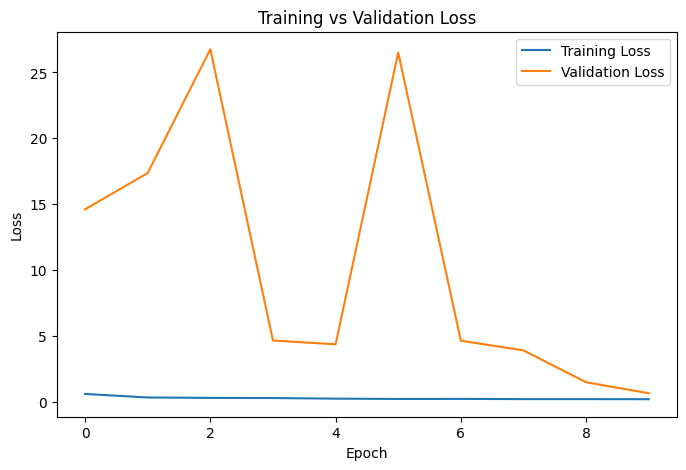

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 387ms/step - accuracy: 0.7532 - loss: 0.7151
Test Loss: 0.7150599956512451
Test Accuracy: 0.7532051205635071


In [ ]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int)

true_classes = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step


In [ ]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.62      0.89      0.73       234
   PNEUMONIA       0.91      0.67      0.77       390

    accuracy                           0.75       624
   macro avg       0.77      0.78      0.75       624
weighted avg       0.80      0.75      0.76       624



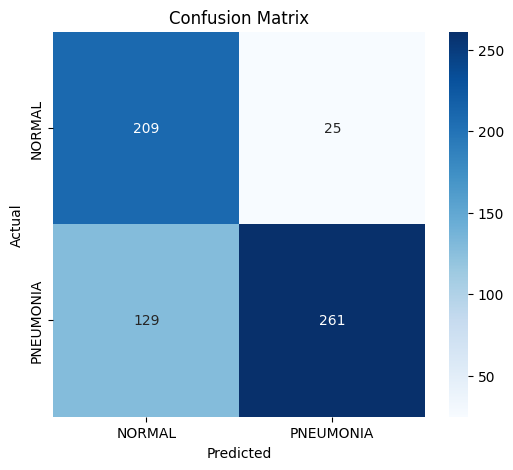

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["NORMAL","PNEUMONIA"],
    yticklabels=["NORMAL","PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction : NORMAL


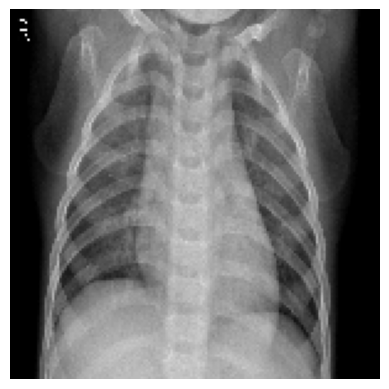

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

sample_image = os.path.join(test_path, "NORMAL", os.listdir(os.path.join(test_path, "NORMAL"))[0])

img = image.load_img(sample_image, target_size=(150,150))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
    print("Prediction : PNEUMONIA")
else:
    print("Prediction : NORMAL")

In [ ]:
model.save("Pneumonia_CNN_Model.keras")

print("Model saved successfully!")

Model saved successfully!
